<a href="https://colab.research.google.com/github/JorgePeje/test-python-utec/blob/main/ConfiabilidadCodigos/DataEvents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
# ============================================================
# 1. CARGAR CSV MANUALMENTE
# ============================================================

from google.colab import files
import pandas as pd

uploaded = files.upload()

archivo = list(uploaded.keys())[0]

print("Archivo cargado:")
print(archivo)


# ============================================================
# 2. LEER CSV WABTEC
# ============================================================

columnas = [
    '#',
    'Type',
    'Event #',
    'Sub ID',
    'Name',
    'Sub ID Name',
    'Time',
    'Restriction',
    'Extra'
]

df = pd.read_csv(
    archivo,
    skiprows=7,     # saltamos también la cabecera original
    names=columnas,
    engine='python'
)




Saving events.csv to events (7).csv
Archivo cargado:
events (7).csv


In [58]:
# ============================================================
# 2. CONVERTIR TIME A DATETIME
# ============================================================

# Quitar =" y " que vienen del archivo Wabtec
df['Time'] = (
    df['Time']
    .str.replace('="', '', regex=False)
    .str.replace('"', '', regex=False)
)

# Convertir a datetime
df['Time'] = pd.to_datetime(
    df['Time'],
    format='%Y-%m-%d %H:%M:%S.%f'
)

# Verificar resultado
print("Tipo de dato:")
print(df['Time'].dtype)

print("\nPrimeras fechas:")
print(df['Time'].head())

Tipo de dato:
datetime64[ns]

Primeras fechas:
0   2026-08-26 20:05:41.438
1   2026-08-26 18:00:24.674
2   2026-08-26 18:00:24.594
3   2026-08-26 17:59:36.600
4   2026-08-26 17:52:36.191
Name: Time, dtype: datetime64[ns]


In [59]:
# ============================================================
# 3. CREAR CÓDIGO Y DESCRIPCIÓN DEL EVENTO
# ============================================================

df['Codigo'] = (
    df['Event #'].astype(str)
    + '-'
    + df['Sub ID'].astype(str)
)

df['Name / SubIDName'] = (
    df['Name'].fillna('').astype(str).str.strip()
    + ' / '
    + df['Sub ID Name'].fillna('').astype(str).str.strip()
)

display(df.head(10))

# ============================================================
# 4. INTERVALO DE FECHAS ANALIZADO
# ============================================================

fecha_min = df['Time'].min()
fecha_max = df['Time'].max()

print("Fecha mínima:", fecha_min)
print("Fecha máxima:", fecha_max)
print("Intervalo:", fecha_max - fecha_min)

,#,Type,Event #,Sub ID,Name,Sub ID Name,Time,Restriction,Extra,Codigo,Name / SubIDName
0,0,----,700,0,--System power-up--,--System power-up--,2026-08-26 20:05:41.438,Non-restrictive event,None,700-0,--System power-up-- / --System power-up--
1,1,Log,81,2,Quad chopper fault,Link I sensor - high value,2026-08-26 18:00:24.674,Speed limit,None,81-2,Quad chopper fault / Link I sensor - high value
2,2,Log,81,1,Quad chopper fault,Grid I sensor - high value,2026-08-26 18:00:24.594,Speed limit,None,81-1,Quad chopper fault / Grid I sensor - high value
3,3,----,700,0,--System power-up--,--System power-up--,2026-08-26 17:59:36.600,Non-restrictive event,None,700-0,--System power-up-- / --System power-up--
4,4,Log,33,1,RP or chopper HP balance,May be shorted or stuck closed,2026-08-26 17:52:36.191,Speed limit,EngSpd RP,33-1,RP or chopper HP balance / May be shorted or s...
5,5,Log,81,1,Quad chopper fault,Grid I sensor - high value,2026-08-26 17:52:36.189,Speed limit,None,81-1,Quad chopper fault / Grid I sensor - high value
6,6,Log,81,2,Quad chopper fault,Link I sensor - high value,2026-08-26 17:52:36.186,Speed limit,None,81-2,Quad chopper fault / Link I sensor - high value
7,8,----,700,0,--System power-up--,--System power-up--,2026-08-26 15:01:01.606,Non-restrictive event,None,700-0,--System power-up-- / --System power-up--
8,9,----,706,0,System in safe mode,System in safe mode,2026-08-26 14:46:22.726,Non-restrictive event,None,706-0,System in safe mode / System in safe mode
9,10,SRst,643,2,Cabinet pressure out of limits,Sensor high with engine off,2026-08-26 08:56:19.856,Speed limit,None,643-2,Cabinet pressure out of limits / Sensor high w...


Fecha mínima: 2026-07-07 13:10:06.517000
Fecha máxima: 2026-08-26 20:05:41.438000
Intervalo: 50 days 06:55:34.921000


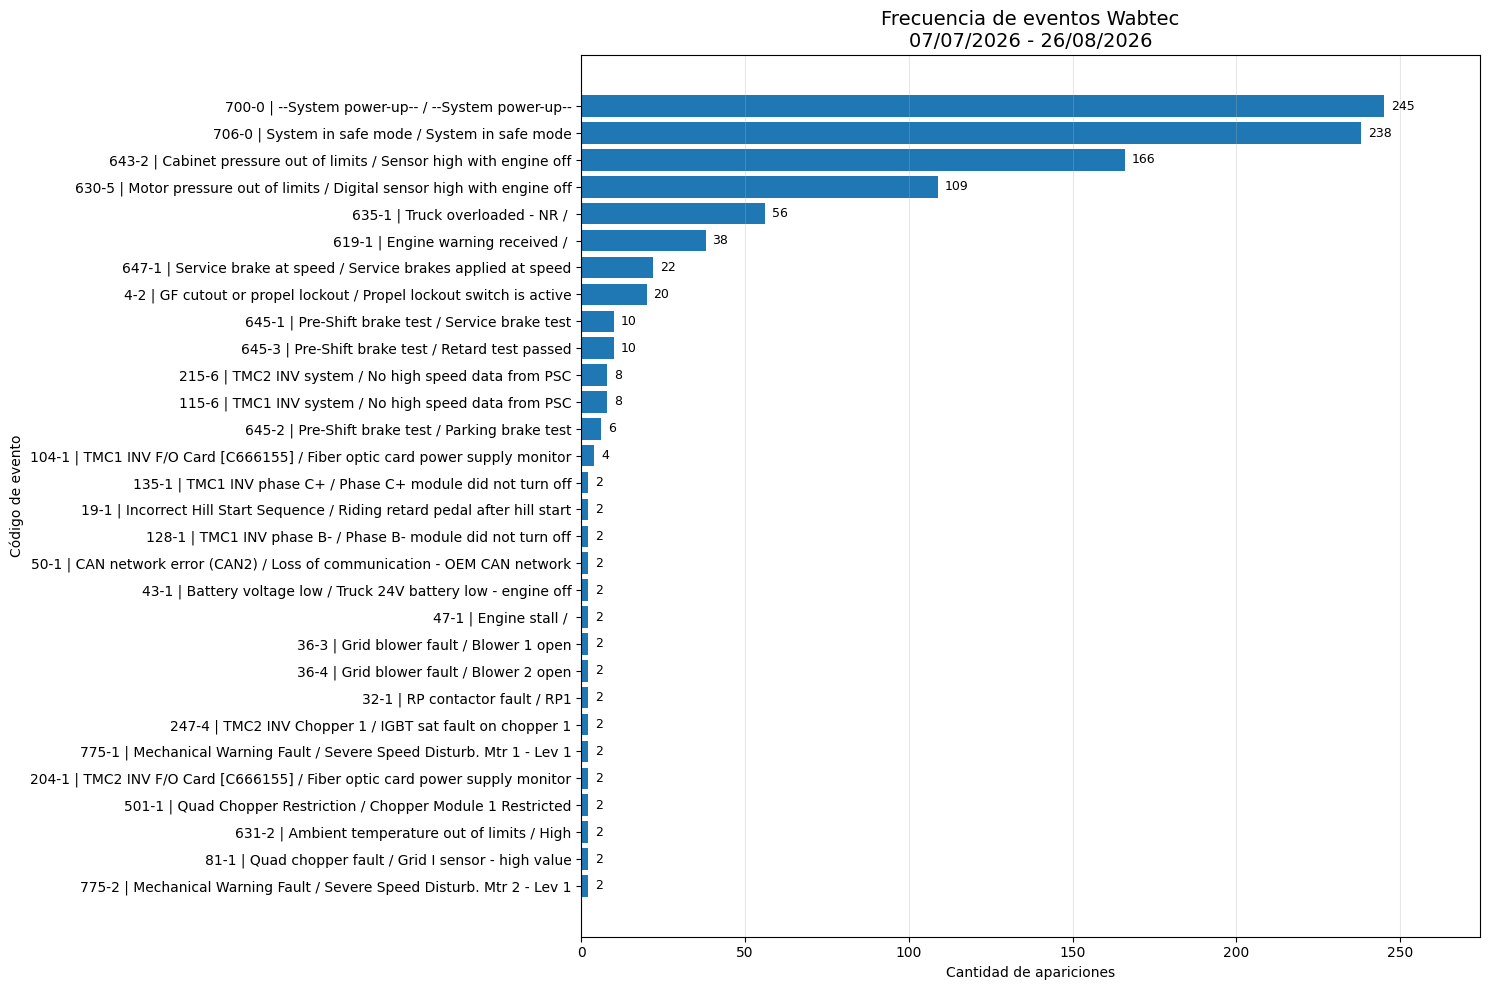

In [60]:
# ============================================================
# 5. GRÁFICO DE FRECUENCIA DE EVENTOS
# ============================================================

# Contar frecuencia por código y descripción
frecuencia = (
    df
    .groupby(['Codigo', 'Name / SubIDName'])
    .size()
    .reset_index(name='Cantidad')
    .sort_values(
        'Cantidad',
        ascending=False
    )
)


# Mostrar tabla de los 30 más frecuentes
#display(frecuencia.head(30))


# Seleccionar los 30 códigos más frecuentes
top = frecuencia.head(30).copy()


# Crear etiqueta para el gráfico:
# Código | Descripción
top['Etiqueta'] = (
    top['Codigo']
    + ' | '
    + top['Name / SubIDName']
)


# ============================================================
# CREAR GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(15, 10))


barras = ax.barh(
    top['Etiqueta'],
    top['Cantidad']
)


# Mostrar cantidad al final de cada barra
ax.bar_label(
    barras,
    labels=top['Cantidad'],
    padding=5,
    fontsize=9
)


# Títulos
ax.set_xlabel('Cantidad de apariciones')
ax.set_ylabel('Código de evento')

ax.set_title(
    f'Frecuencia de eventos Wabtec\n'
    f'{fecha_min:%d/%m/%Y} - {fecha_max:%d/%m/%Y}',
    fontsize=14
)


# Código más frecuente arriba
ax.invert_yaxis()


# Cuadrícula
ax.grid(
    axis='x',
    alpha=0.3
)


# Dar espacio para que no se corte el valor
ax.set_xlim(
    0,
    top['Cantidad'].max() * 1.12
)


plt.tight_layout()

plt.show()

Intervalo analizado:
Inicio : 2026-08-20 01:00:00
Fin    : 2026-08-26 20:20:00
Eventos: 161


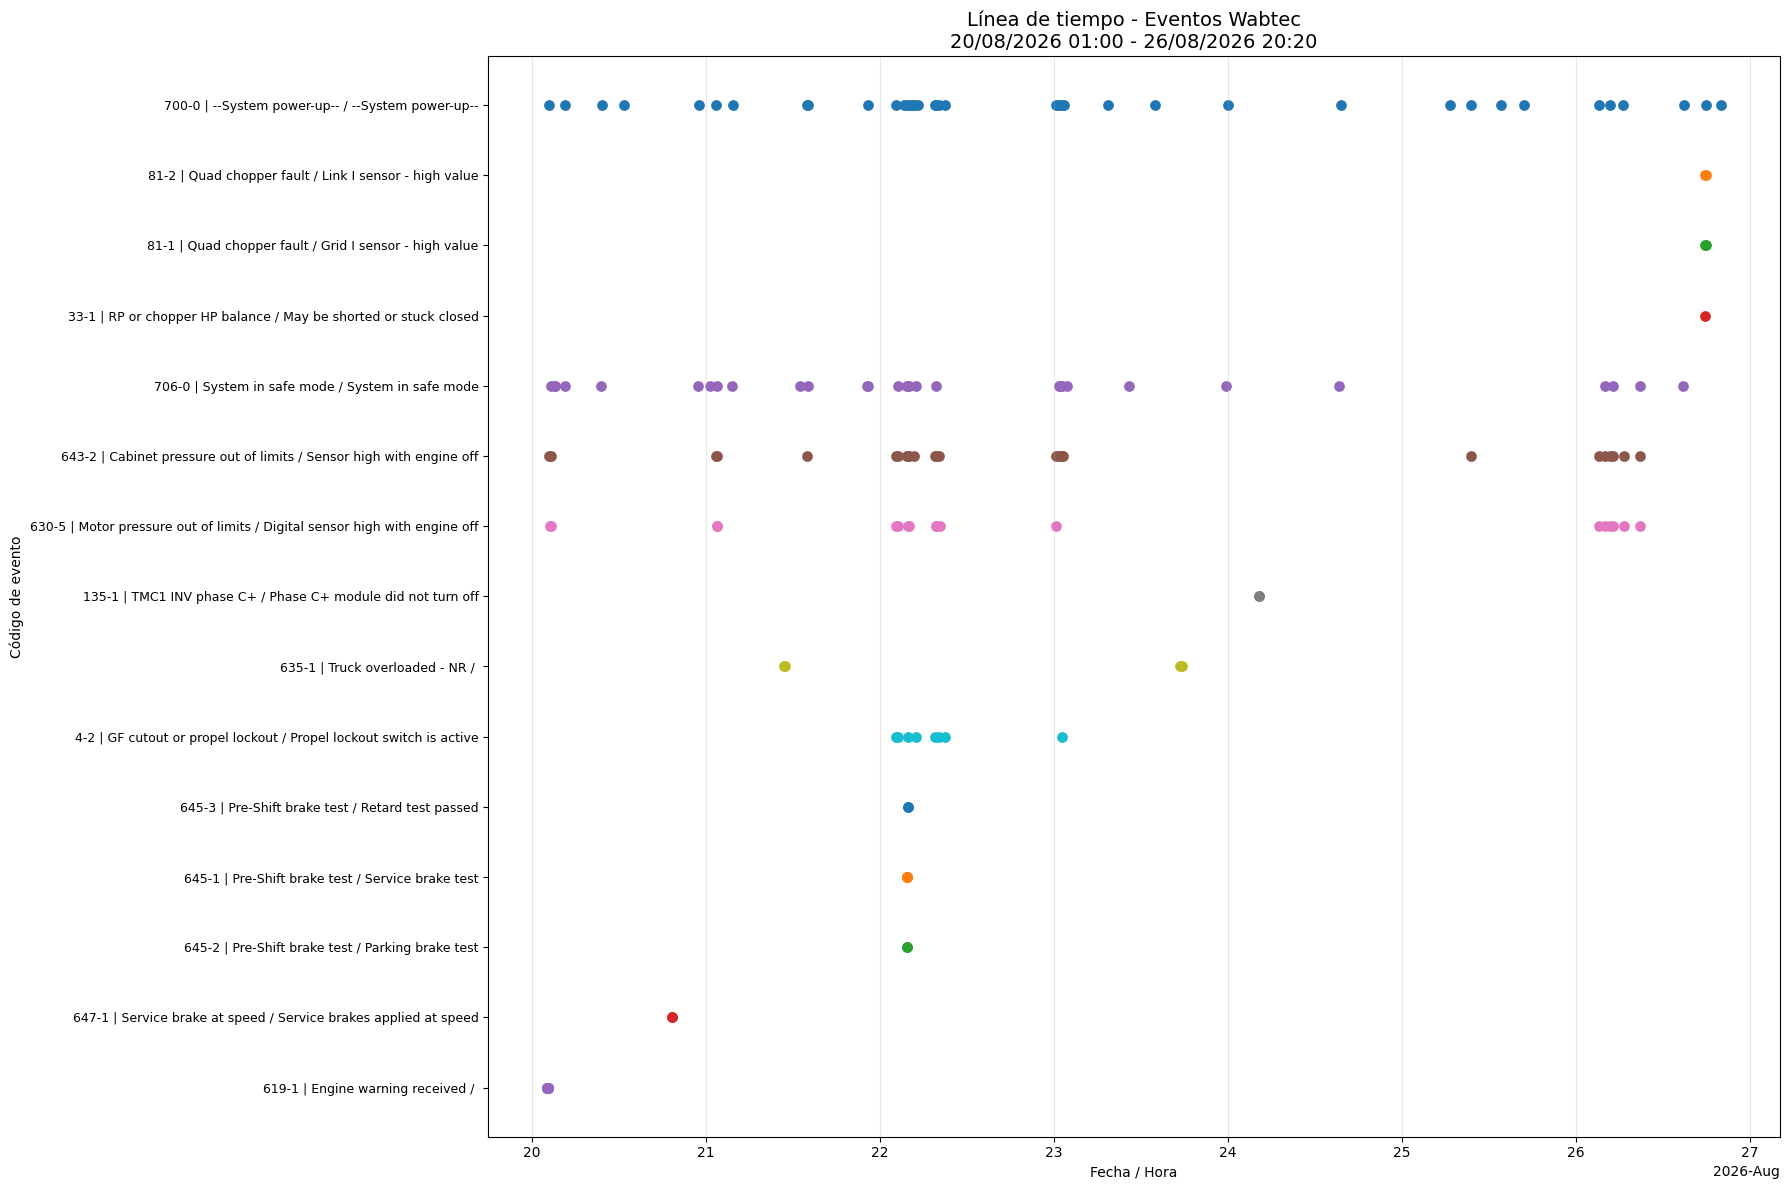

In [65]:
# ============================================================
# 9. LÍNEA DE TIEMPO - TOP 30 EVENTOS
# ============================================================

import matplotlib.dates as mdates


# ============================================================
# DEFINIR INTERVALO DE ANÁLISIS
# ============================================================

# Modifica solamente estas dos fechas
fecha_inicio = pd.Timestamp('2026-08-20 01:00:00')
fecha_fin    = pd.Timestamp('2026-08-26 20:20:00')


# Filtrar datos dentro del intervalo
df_intervalo = df[
    (df['Time'] >= fecha_inicio) &
    (df['Time'] <= fecha_fin)
].copy()


print("Intervalo analizado:")
print("Inicio :", fecha_inicio)
print("Fin    :", fecha_fin)
print("Eventos:", len(df_intervalo))


# ============================================================
# CALCULAR FRECUENCIA DENTRO DEL INTERVALO
# ============================================================

frecuencia_intervalo = (
    df_intervalo
    .groupby(
        ['Codigo', 'Name / SubIDName']
    )
    .size()
    .reset_index(name='Cantidad')
    .sort_values(
        'Cantidad',
        ascending=False
    )
)



# ============================================================
# CREAR ETIQUETA: CÓDIGO | DESCRIPCIÓN
# ============================================================

df_intervalo['Etiqueta'] = (
    df_intervalo['Codigo']
    + ' | '
    + df_intervalo['Name / SubIDName']
)


# ============================================================
# MANTENER EL ORDEN SEGÚN FRECUENCIA
# ============================================================

orden_etiquetas = (
    df_intervalo['Etiqueta']
    .drop_duplicates()
    .tolist()
)


# ============================================================
# CREAR GRÁFICO
# ============================================================

fig, ax = plt.subplots(
    figsize=(18, 12)
)


for i, etiqueta in enumerate(orden_etiquetas):

    datos_evento = df_intervalo[
    df_intervalo['Etiqueta'] == etiqueta
    ]

    ax.scatter(
        datos_evento['Time'],
        [i] * len(datos_evento),
        s=45
    )


# ============================================================
# CONFIGURAR EJE Y
# ============================================================

ax.set_yticks(
    range(len(orden_etiquetas))
)

ax.set_yticklabels(
    orden_etiquetas,
    fontsize=9
)

# Más frecuente arriba
ax.invert_yaxis()


# ============================================================
# TÍTULOS
# ============================================================

ax.set_xlabel(
    'Fecha / Hora'
)

ax.set_ylabel(
    'Código de evento'
)

ax.set_title(
    f'Línea de tiempo - Eventos Wabtec\n'
    f'{fecha_inicio:%d/%m/%Y %H:%M} - '
    f'{fecha_fin:%d/%m/%Y %H:%M}',
    fontsize=14
)


# ============================================================
# FORMATO DEL EJE X
# ============================================================

# Formato automático de fecha/hora
locator = mdates.AutoDateLocator()

formatter = mdates.ConciseDateFormatter(
    locator
)

ax.xaxis.set_major_locator(
    locator
)

ax.xaxis.set_major_formatter(
    formatter
)


# ============================================================
# CUADRÍCULA
# ============================================================

ax.grid(
    axis='x',
    alpha=0.3
)


# ============================================================
# MOSTRAR GRÁFICO
# ============================================================

plt.tight_layout()

plt.show()
